This notebook builds on pandas data processing notebook, includes plotting

Import pandas, numpy, matplotlib and read the desired data file

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

df = pd.read_csv('pandas_practice/fortune1000.csv',encoding='latin1')

Code to keep only stats that indicate current performance

In [58]:
print(df.columns)
df = df.rename(columns={'Revenue Change':'Revenue Change %','Profit Change':'Profit Change %'})
df_numeric = df.iloc[:,:10].copy()

Index(['rank', 'title', 'Previous Rank', 'Revenues ($M)', 'Revenue Change',
       'Profits ($M)', 'Profit Change', 'Assets ($M)',
       'Mkt Value as of 3/29/18 ($M)', 'Employees', 'CEO', 'CEO Title',
       'Sector', 'Industry', 'Years on Fortune 500 List', 'City', 'State',
       'Latitude', 'Longitude'],
      dtype='str')


Clean strings to include only numbers for analysis

In [59]:
#clean numeric data to remove $ , % symbols so that it
#can be converted to integers, ignoring title column
for col in df_numeric.columns:
    if col =='title':
        continue
    if pd.api.types.is_string_dtype(df_numeric[col]):
        cleaned_df = df_numeric[col].astype(str).str.replace(r'[\s,\$%]','', regex=True)
        df_numeric[col] = pd.to_numeric(cleaned_df, errors='coerce')

#create new column: rank increase
#remove rows where either rank or previous rank has no value

rank_columns = ["rank", "Previous Rank"]

df_numeric[rank_columns] = (
    df_numeric[rank_columns]
    .apply(pd.to_numeric, errors="coerce")
    .astype("Int64")
)
df_numeric = df_numeric.dropna(subset=rank_columns).copy()

df_numeric["Rank increase"] = (
    df_numeric["Previous Rank"] - df_numeric["rank"]
)
#save new cleaned dataframe as csv
df_numeric.to_csv('fortune1000_cleaned.csv', index=False)
        
        
        



Code to print top 5 and bottom 5 companies data

In [60]:
print(df_numeric.head())
print(df_numeric.tail())

   rank               title  Previous Rank  Revenues ($M)  Revenue Change %  \
0     1             Walmart              1       500343.0               3.0   
1     2         Exxon Mobil              4       244363.0              17.4   
2     3  Berkshire Hathaway              2       242137.0               8.3   
3     4               Apple              3       229234.0               6.3   
4     5  UnitedHealth Group              6       201159.0               8.8   

   Profits ($M)  Profit Change %  Assets ($M)  Mkt Value as of 3/29/18 ($M)  \
0        9862.0            -27.7     204522.0                      263563.0   
1       19710.0            151.4     348691.0                      316157.0   
2       44940.0             86.7     702095.0                      492008.0   
3       48351.0              5.8     375319.0                      851318.0   
4       10558.0             50.5     139058.0                      207080.0   

   Employees  Rank increase  
0    2300000        

In [61]:
df_data = df_numeric.describe()
df_data.to_csv('project_data.csv', index=False, na_rep='N/A')

 Create LaTex table with basic stats

In [62]:
#generate summary statistics 
n_rows, n_cols = df_numeric.shape
feature_count = n_cols 
missing_count = df_numeric.isna().sum().sum()
mean_revenue = df_numeric['Revenues ($M)'].mean()
mean_profit = df_numeric['Profits ($M)'].mean()

#create datafile of summary statistics
summary_df = pd.DataFrame({
    "Dataset size": [f"{n_rows} rows x {n_cols} columns"],
    "Feature count": [feature_count],
    "Missing value count": [int(missing_count)],
    "Mean Revenue": [mean_revenue],
    "Mean Profit": [mean_profit]})

#convert datafile to LaTex table
latex_table = summary_df.to_latex(index=False, escape=False)
#print(latex_table)


Code to sort data by profit instead of revenue (descending)

In [63]:
df_by_profit = df_numeric.sort_values(by="Profits ($M)", ascending=False)
#print(df_by_profit.head())

Code to sort data % by growth (revenue increase %, descending)

In [64]:
df_by_revenue_increase = df_numeric.sort_values(by="Revenue Change %", ascending=False)
#print(df_by_revenue_increase.head())

Create plots of Revenue/number of employees, profit/employees, 

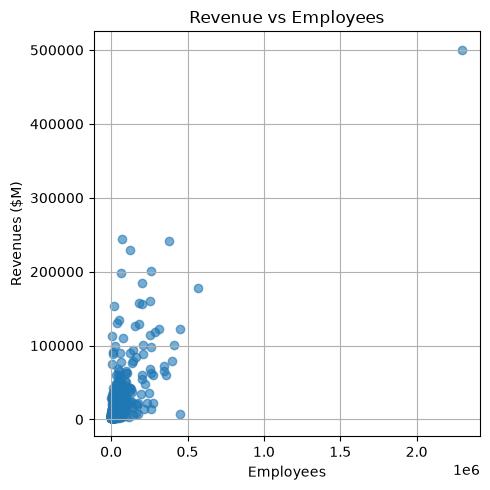

In [65]:
#remove rows where either revenue or number of employees has no value

plot_df = df_numeric.dropna(subset=["Revenues ($M)", "Employees"])
x_vals = plot_df['Employees']
y_vals = plot_df['Revenues ($M)']

plt.figure(figsize=(5, 5))
plt.scatter(x_vals, y_vals, alpha=0.6)
plt.xlabel("Employees")
plt.ylabel("Revenues ($M)")
plt.title("Revenue vs Employees")
plt.grid(True)
plt.tight_layout()
plt.savefig('Figures/plot1.png')
plt.show()


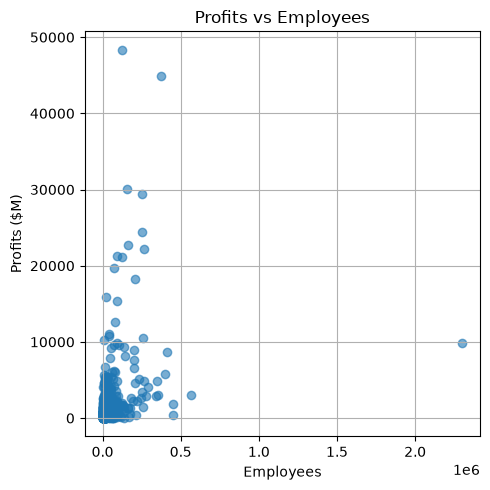

In [66]:
#remove rows where either revenue or number of employees has no value

plot_df = df_numeric.dropna(subset=["Profits ($M)", "Employees"])
x_vals = plot_df['Employees']
y_vals = plot_df['Profits ($M)']

plt.figure(figsize=(5, 5))
plt.scatter(x_vals, y_vals, alpha=0.6)
plt.xlabel("Employees")
plt.ylabel("Profits ($M)")
plt.title("Profits vs Employees")
plt.grid(True)
plt.tight_layout()
plt.savefig('Figures/plot2.png')
plt.show()


Plot increase in rank against revenue change

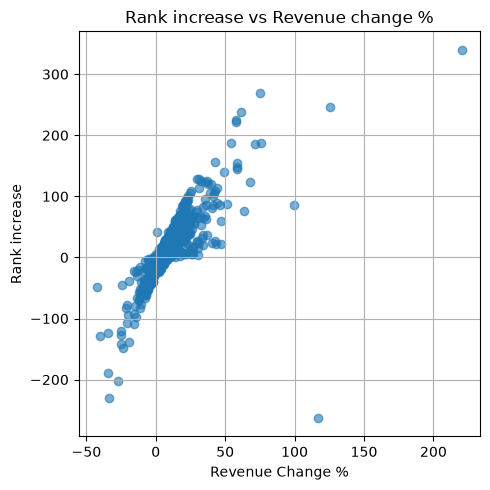

In [67]:

#plot rank increase against revenue change
x_vals = df_numeric['Revenue Change %']
y_vals = df_numeric['Rank increase']

plt.figure(figsize=(5, 5))
plt.scatter(x_vals, y_vals, alpha=0.6)
plt.xlabel("Revenue Change %")
plt.ylabel("Rank increase")
plt.title("Rank increase vs Revenue change %")
plt.grid(True)
plt.tight_layout()
plt.savefig('Figures/plot3.png')
plt.show()
